<a href="https://colab.research.google.com/github/Eaglepop/CS5100_Final_Project/blob/main/5100_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Pneumonia


1 Data preparation

2 Baseline CNN

3 ResNet transfer learning

4 GAN data augmentation

5 Genetic Algorithm hyperparameter search --> Grid and Optuna

6 Evaluation


## 1. Data Preparation

load dataset\
split dataset\
image preprocessing


torchvision\
PIL\
numpy


In [1]:
!pip install torch torchvision
!pip install kaggle
!pip install scikit-learn
!pip install torch torchvision scikit-learn matplotlib

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os

import kagglehub

In [3]:
# chest_xray/
#     train/
#         NORMAL/
#         PNEUMONIA/
#     val/
#         NORMAL/
#         PNEUMONIA/
#     test/
#         NORMAL/
#         PNEUMONIA/

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

path = os.path.join(path, "chest_xray")

#Grep train, test, val data
train_dir = os.path.join(path, "train")
val_dir = os.path.join(path, "val")
test_dir = os.path.join(path, "test")

# Preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# load dataset
train_dataset = ImageFolder(train_dir, transform=transform)
val_dataset = ImageFolder(val_dir, transform=transform)
test_dataset = ImageFolder(test_dir, transform=transform)

print("Path to dataset files:", path)
print(train_dataset.classes) #['NORMAL', 'PNEUMONIA']


Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia
Path to dataset files: /kaggle/input/chest-xray-pneumonia/chest_xray
['NORMAL', 'PNEUMONIA']


In [4]:
# Set batch to 32 then load
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) # make sure photos will not always the same
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False) # only looking for the result
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False) # only looking for the result

print("Train size:", len(train_dataset)) #5216
print("Validation size:", len(val_dataset)) #16
print("Test size:", len(test_dataset)) #624

Train size: 5216
Validation size: 16
Test size: 624


In [5]:
# print nums of pneumonia and normal in every sets

from collections import Counter

def count_classes(dataset, name):
    # read only target
    labels = dataset.targets
    counts = Counter(labels)

    # build mapping
    class_to_idx = dataset.class_to_idx
    idx_to_class = {v: k for k, v in class_to_idx.items()}

    print(f"{name} Set:")
    for idx, count in counts.items():
        print(f"  {idx_to_class[idx]}: {count}")
    print(f"  Total: {len(labels)}\n")

count_classes(train_dataset, "Train")
count_classes(val_dataset, "Validation")
count_classes(test_dataset, "Test")

Train Set:
  NORMAL: 1341
  PNEUMONIA: 3875
  Total: 5216

Validation Set:
  NORMAL: 8
  PNEUMONIA: 8
  Total: 16

Test Set:
  NORMAL: 234
  PNEUMONIA: 390
  Total: 624



tensor([0, 1, 1, 1, 1, 1, 0, 1])
torch.Size([32, 3, 224, 224])
['NORMAL', 'PNEUMONIA']


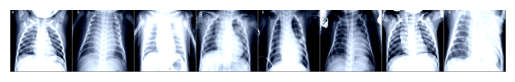

In [6]:
# Only for visualization

# Denormalization 0~1
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis("off")


dataiter = iter(train_loader) # initialize
images, labels = next(dataiter) # get one batch

imshow(torchvision.utils.make_grid(images[:8]))
print(labels[:8])

print(images.shape) #torch.Size([32, 3, 224, 224])
# 32,         3,           224,    224
# batch_size, RGB channel, height, width

class_names = train_dataset.classes
print(class_names)

## 2. Baseline CNN

Conv\
ReLU\
MaxPool\
Conv\
ReLU\
MaxPool\
Fully connected\
Softmax

In [7]:
import torch.nn as nn           # instance
import torch.nn.functional as F # Calculate

In [8]:
# establish baseline CNN model
class SimpleCNN(nn.Module):

    def __init__(self): #initializtion
        super(SimpleCNN, self).__init__()

        #nn.Conv2d(in, out, kernel, padding)

        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)

        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)

        self.fc1 = nn.Linear(32 * 56 * 56, 128)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):

        #224*224*3
        x = self.pool(F.relu(self.conv1(x))) #112*112*16
        #112*112*16
        x = self.pool(F.relu(self.conv2(x))) #56*56*32

        #Flatten to 1d line with length == 56*56*32
        x = x.view(x.size(0), -1) # size(0)= default batch size (32), -1: calculate it automatically
        #x.size() = [batch, channel, length, width] --> 32, 32, 56, 56

        x = F.relu(self.fc1(x)) # 32 * 56 * 56 --> 128
        x = self.fc2(x) # 128 --> 2

        return x # (x is logits(can >1, <0), not confidence(prob) yet)

In [9]:
# set up env
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # specify env

model = SimpleCNN().to(device) # put model into env

print(model)


SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=100352, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)


In [10]:
#loss
criterion = nn.CrossEntropyLoss() #loss as criterion

#optimizer: Adam
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [11]:
#Training loop

#input batch
#generate logits
#criterion calculate loss
#.backward find gradients
#optimizer.step revise parameters

epochs = 5

for epoch in range(epochs):

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad() # reset to 0

        outputs = model(images) # train in model(simpleCNN)

        loss = criterion(outputs, labels) # grading

        loss.backward() # back propagation

        optimizer.step() # gradually optimize

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.3027
Epoch 2, Loss: 0.0724
Epoch 3, Loss: 0.0464
Epoch 4, Loss: 0.0241
Epoch 5, Loss: 0.0118


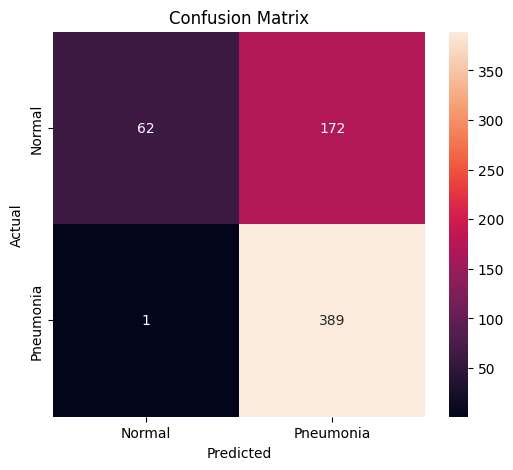

              precision    recall  f1-score   support

           0       0.98      0.26      0.42       234
           1       0.69      1.00      0.82       390

    accuracy                           0.72       624
   macro avg       0.84      0.63      0.62       624
weighted avg       0.80      0.72      0.67       624



In [12]:
# evaluation
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
import seaborn as sns

all_preds=[]  # predict labels
all_labels=[] # true labels
all_probs=[]  # probabilities of Pnuemonia

model.eval() # set model to evaluation mode

# eval loop
with torch.no_grad(): # do not track gradient in order to decrease the using of the resources (we don't have to update parameters during evaluation)

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images) # oroginal output (logits)

        probs = torch.softmax(outputs, dim=1) # turn logits into probabilities (sum=1 in each class)

        _, predicted = torch.max(outputs, 1) # _ is the max logit in the original output, we do not need this anymore so just recieve "predicted" which is 0 or 1

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:,1].cpu().numpy())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Normal','Pneumonia'],
            yticklabels=['Normal','Pneumonia'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Precision / Recall / F1 score
print(classification_report(all_labels, all_preds))


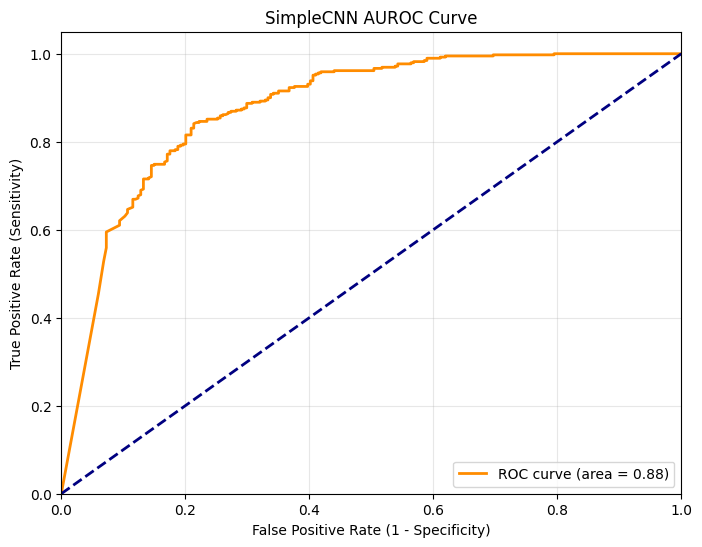

ROC-AUC Score: 0.8781


In [13]:
# AUROC curve
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate points of ROC curve (FPR, TPR)
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

# Calculate roc_auc
roc_auc = auc(fpr, tpr)

# draw the curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05]) # give the curve more space
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('SimpleCNN AUROC Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")


## 3. Resnet Transfer Learning

load pretrained resnet\
replace final layer\
train classifier

In [14]:
import torchvision.models as models

# model = models.resnet18(pretrained = True) # conventional
model = models.resnet18(weights='DEFAULT') # select the most suitable weight

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 149MB/s]


In [15]:
num_ft = model.fc.in_features
model.fc = nn.Linear(num_ft,2)

In [16]:
for param in model.parameters():
  param.requires_grad = False

for param in model.fc.parameters():
  param.requires_grad = True

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [18]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

In [19]:
epochs = 5

for epoch in range(epochs):
  model.train()
  running_loss=0

  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)

    loss = criterion(outputs, labels)

    loss.backward()

    optimizer.step()

    running_loss += loss.item()

  print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

Epoch 1/5, Loss: 0.2789
Epoch 2/5, Loss: 0.1735
Epoch 3/5, Loss: 0.1456
Epoch 4/5, Loss: 0.1328
Epoch 5/5, Loss: 0.1268


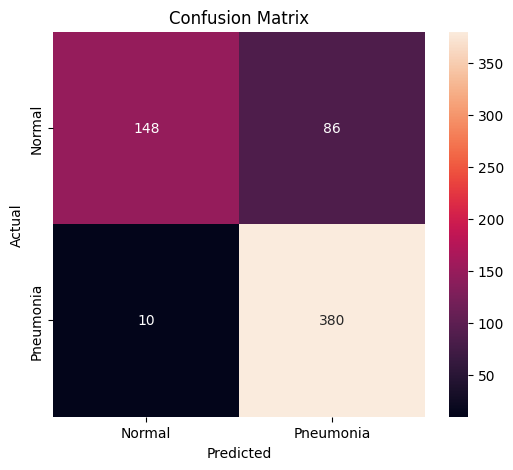

              precision    recall  f1-score   support

           0       0.94      0.63      0.76       234
           1       0.82      0.97      0.89       390

    accuracy                           0.85       624
   macro avg       0.88      0.80      0.82       624
weighted avg       0.86      0.85      0.84       624



In [20]:
# evaluation
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
import seaborn as sns

all_preds=[]  # predict labels
all_labels=[] # true labels
all_probs=[]  # probabilities of Pnuemonia

model.eval() # set model to evaluation mode

# eval loop
with torch.no_grad(): # do not track gradient in order to decrease the using of the resources (we don't have to update parameters during evaluation)

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images) # oroginal output (logits)

        probs = torch.softmax(outputs, dim=1) # turn logits into probabilities (sum=1 in each class)

        _, predicted = torch.max(outputs, 1) # _ is the max logit in the original output, we do not need this anymore so just recieve "predicted" which is 0 or 1

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:,1].cpu().numpy())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Normal','Pneumonia'],
            yticklabels=['Normal','Pneumonia'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Precision / Recall / F1 score
print(classification_report(all_labels, all_preds))


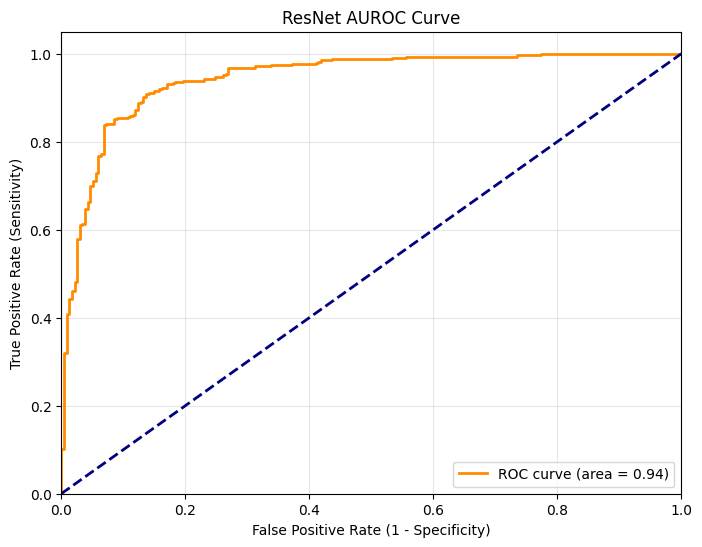

ROC-AUC Score: 0.9445


In [21]:
# AUROC curve
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate points of ROC curve (FPR, TPR)
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

# Calculate roc_auc
roc_auc = auc(fpr, tpr)

# draw the curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ResNet AUROC Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")


## 4. GAN Data Augmentation

train GAN\
generate images\
add to dataset

In [22]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torchvision.utils as vutils

In [23]:
image_size = 64   # set smaller size for GAN
batch_size = 64
nz = 100          # noise vector

In [24]:
transform_gan = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.Grayscale(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [25]:
gan_dataset = ImageFolder(train_dir, transform=transform_gan)

# only get NORMAL（label = 0）
indices = [i for i, (_, label) in enumerate(gan_dataset) if label == 0]

gan_subset = torch.utils.data.Subset(gan_dataset, indices)

gan_loader = DataLoader(gan_subset, batch_size=batch_size, shuffle=True)

In [26]:
class Generator(nn.Module):
    def __init__(self, nz=100):
        super().__init__()
        self.main = nn.Sequential(

            # input nz x 1 x 1 -> output 512 x 4 x 4
            nn.ConvTranspose2d(nz, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            # 4x4 -> 8x8
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # 8x8 -> 16x16
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # 16x16 -> 32x32
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # 32x32 -> 64x64
            nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.main(x)

In [27]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(

            # 1 x 64 x 64 -> 64 x 32 x 32
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 x 32 -> 16 x 16
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # 16 x 16 -> 8 x 8
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # 8 x 8 -> 4 x 4
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),
            nn.Linear(512 * 4 * 4, 1), # fit 4x4
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x)


In [28]:
# initialization
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

netG = Generator().to(device)
netD = Discriminator().to(device)

criterion = nn.BCELoss()

optimizerG = torch.optim.Adam(netG.parameters(), lr=0.0002)
optimizerD = torch.optim.Adam(netD.parameters(), lr=0.0002)

In [29]:
epochs = 5

for epoch in range(epochs):
    for real, _ in gan_loader:

        real = real.to(device)   # already grayscale，do not need [:,0:1,:,:] anymore

        b_size = real.size(0)

        label_real = torch.ones(b_size, 1).to(device)
        label_fake = torch.zeros(b_size, 1).to(device)

        # --- Train Discriminator ---
        output_real = netD(real)
        loss_real = criterion(output_real, label_real)

        noise = torch.randn(b_size, nz, 1, 1).to(device)
        fake = netG(noise)

        output_fake = netD(fake.detach())
        loss_fake = criterion(output_fake, label_fake)

        lossD = loss_real + loss_fake

        optimizerD.zero_grad()
        lossD.backward()
        optimizerD.step()

        # --- Train Generator ---
        output = netD(fake)
        lossG = criterion(output, label_real)

        optimizerG.zero_grad()
        lossG.backward()
        optimizerG.step()

    print(f"Epoch {epoch+1} done")

Epoch 1 done
Epoch 2 done
Epoch 3 done
Epoch 4 done
Epoch 5 done


In [30]:
num_generate = 300

noise = torch.randn(num_generate, nz, 1, 1).to(device)
fake_images = netG(noise)

In [31]:
import os
import shutil


source_train = os.path.join(path, "train")
target_train = "chest_xray_augmented/train"

# use absolute path to move
shutil.copytree(source_train, target_train, dirs_exist_ok=True)

# use absolute path
save_dir = os.path.join(target_train, "NORMAL")
os.makedirs(save_dir, exist_ok=True)

# save each images
for i in range(fake_images.size(0)):
    vutils.save_image(fake_images[i], os.path.join(save_dir, f"gan_normal_{i}.png"), normalize=True)


In [32]:
## ResNet + GAN


# ensure the path
train_dir = target_train

# use absolute path
val_dir = os.path.join(path, "val")
test_dir = os.path.join(path, "test")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),  # ResNet requires 3 channels
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                     [0.229, 0.224, 0.225])
])

train_dataset = ImageFolder(train_dir, transform=transform)
val_dataset = ImageFolder(val_dir, transform=transform)
test_dataset = ImageFolder(test_dir, transform=transform)


print(f"OG NORMAL count: 1341")
print(f"GAN count: {num_generate}")
print(f"all train count: {len(train_dataset)}")



train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)



# model = models.resnet18(pretrained = True) # conventional
model = models.resnet18(weights='DEFAULT') # select the most suitable weight



num_ft = model.fc.in_features
model.fc = nn.Linear(num_ft,2)



for param in model.parameters():
  param.requires_grad = False

for param in model.fc.parameters():
  param.requires_grad = True



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)



criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)



epochs = 5

for epoch in range(epochs):
  model.train()
  running_loss=0

  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)

    loss = criterion(outputs, labels)

    loss.backward()

    optimizer.step()

    running_loss += loss.item()

  print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")




OG NORMAL count: 1341
GAN count: 300
all train count: 5516
Epoch 1/5, Loss: 0.2644
Epoch 2/5, Loss: 0.1678
Epoch 3/5, Loss: 0.1508
Epoch 4/5, Loss: 0.1236
Epoch 5/5, Loss: 0.1217


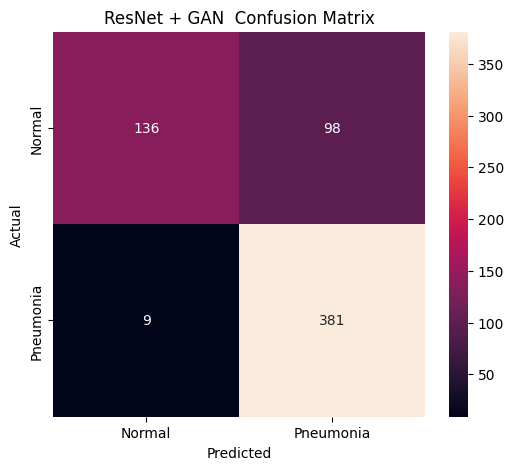

              precision    recall  f1-score   support

           0       0.94      0.58      0.72       234
           1       0.80      0.98      0.88       390

    accuracy                           0.83       624
   macro avg       0.87      0.78      0.80       624
weighted avg       0.85      0.83      0.82       624



In [33]:
# evaluation
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
import seaborn as sns

all_preds=[]  # predict labels
all_labels=[] # true labels
all_probs=[]  # probabilities of Pnuemonia

model.eval() # set model to evaluation mode

# eval loop
with torch.no_grad(): # do not track gradient in order to decrease the using of the resources (we don't have to update parameters during evaluation)

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images) # oroginal output (logits)

        probs = torch.softmax(outputs, dim=1) # turn logits into probabilities (sum=1 in each class)

        _, predicted = torch.max(outputs, 1) # _ is the max logit in the original output, we do not need this anymore so just recieve "predicted" which is 0 or 1

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:,1].cpu().numpy())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Normal','Pneumonia'],
            yticklabels=['Normal','Pneumonia'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet + GAN  Confusion Matrix")
plt.show()

# Precision / Recall / F1 score
print(classification_report(all_labels, all_preds))


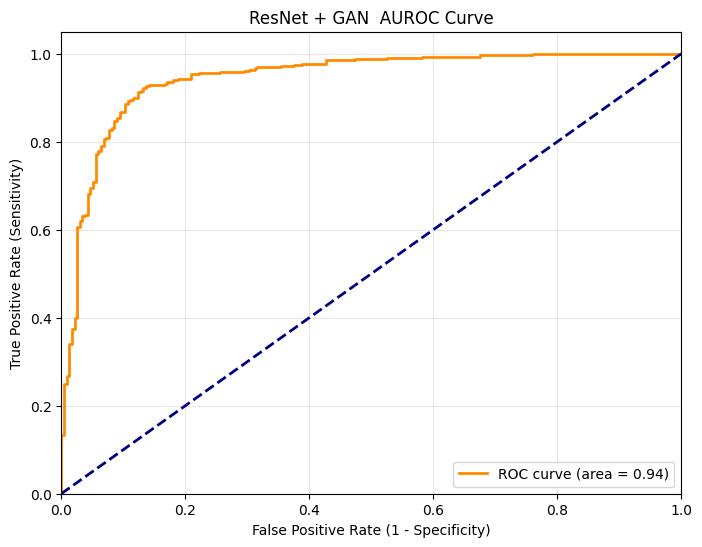

ROC-AUC Score: 0.9448


In [34]:
# AUROC curve
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate points of ROC curve (FPR, TPR)
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

# Calculate roc_auc
roc_auc = auc(fpr, tpr)

# draw the curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ResNet + GAN  AUROC Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")

## 5. Grid Hyperparamter Search

learning rate\
batch size\
optimizer\
dropout

In [35]:
path = os.path.join(path, "chest_xray")

#Grep train, test, val data
train_dir = os.path.join(path, "train")
val_dir = os.path.join(path, "val")
test_dir = os.path.join(path, "test")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = ImageFolder(train_dir, transform=transform)
test_dataset = ImageFolder(test_dir, transform=transform)


In [36]:
# Grid setting
learning_rates = [0.001, 0.0001]
batch_sizes = [16, 32]


best_acc = 0
best_config = {}
best_model = None

for lr in learning_rates:
    for batch_size in batch_sizes:

        print(f"\nRunning: lr={lr}, batch_size={batch_size}")

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

        # Model
        model = models.resnet18(weights='DEFAULT')
        num_ft = model.fc.in_features
        model.fc = nn.Linear(num_ft, 2)

        # Freeze
        for param in model.parameters():
            param.requires_grad = False
        for param in model.fc.parameters():
            param.requires_grad = True

        model = model.to(device)

        # Loss
        criterion = nn.CrossEntropyLoss()

        # Optimizer
        optimizer = torch.optim.Adam(model.fc.parameters(), lr=lr)

        # Train
        epochs = 5
        for epoch in range(epochs):
            model.train()
            for images, labels in train_loader:

                images = images.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

        # Evaluate (accuracy)
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                _, predicted = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        acc = 100 * correct / total
        print(f"Accuracy: {acc:.2f}%")

        # Save best model
        if acc > best_acc:
            best_acc = acc
            best_config = {"lr": lr, "batch_size": batch_size}
            best_model = model


Running: lr=0.001, batch_size=16
Accuracy: 81.57%

Running: lr=0.001, batch_size=32
Accuracy: 76.12%

Running: lr=0.0001, batch_size=16
Accuracy: 81.73%

Running: lr=0.0001, batch_size=32
Accuracy: 81.73%


In [37]:
print("\nBest Config:", best_config)
print("Best Accuracy:", best_acc)


Best Config: {'lr': 0.0001, 'batch_size': 16}
Best Accuracy: 81.73076923076923


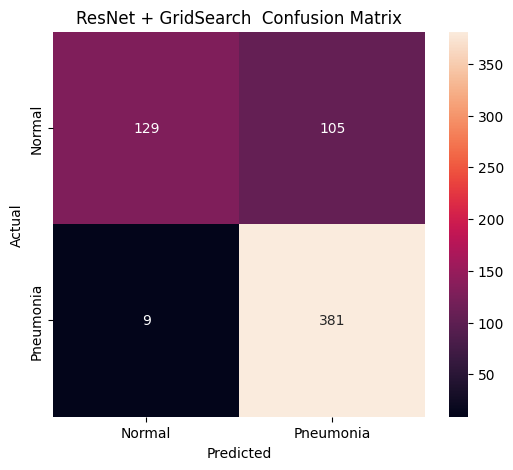

              precision    recall  f1-score   support

           0       0.93      0.55      0.69       234
           1       0.78      0.98      0.87       390

    accuracy                           0.82       624
   macro avg       0.86      0.76      0.78       624
weighted avg       0.84      0.82      0.80       624



In [38]:
# evaluation

# use best set
model = best_model


all_preds=[]  # predict labels
all_labels=[] # true labels
all_probs=[]  # probabilities of Pnuemonia

model.eval() # set model to evaluation mode

# eval loop
with torch.no_grad(): # do not track gradient in order to decrease the using of the resources (we don't have to update parameters during evaluation)

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images) # oroginal output (logits)

        probs = torch.softmax(outputs, dim=1) # turn logits into probabilities (sum=1 in each class)

        _, predicted = torch.max(outputs, 1) # _ is the max logit in the original output, we do not need this anymore so just recieve "predicted" which is 0 or 1

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:,1].cpu().numpy())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Normal','Pneumonia'],
            yticklabels=['Normal','Pneumonia'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet + GridSearch  Confusion Matrix")
plt.show()

# Precision / Recall / F1 score
print(classification_report(all_labels, all_preds))


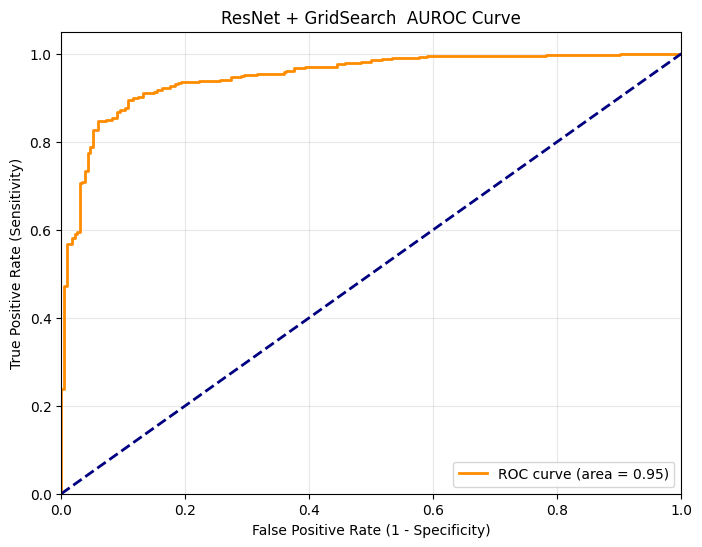

ROC-AUC Score: 0.9490


In [39]:
# AUROC curve
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate points of ROC curve (FPR, TPR)
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

# Calculate roc_auc
roc_auc = auc(fpr, tpr)

# draw the curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ResNet + GridSearch  AUROC Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")

## 6. Optuna Hyperparamter Search

learning rate\
batch size\
optimizer\
dropout

In [40]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.3 MB/s eta 0:00:00


In [ ]:
import optuna
from torch import nn
import torchvision.models as models
from torch.utils.data import DataLoader

def objective(trial):

    # --- Hyperparameters to search ---
    lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64])
    epochs = trial.suggest_int('epochs', 3, 10)
    dropout = trial.suggest_float('dropout', 0.0, 0.5)
    unfreeze = trial.suggest_categorical('unfreeze', ['fc_only', 'layer4_fc', 'layer3_layer4_fc'])
    normal_weight = trial.suggest_float('normal_weight', 1.0, 4.0)

    # --- Data ---
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

    # --- Fresh model ---
    model = models.resnet18(weights='DEFAULT')
    num_ft = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(num_ft, 2)
    )

    # --- Unfreezing ---
    for param in model.parameters():
        param.requires_grad = False

    if unfreeze == 'layer4_fc':
        for param in model.layer4.parameters():
            param.requires_grad = True
    elif unfreeze == 'layer3_layer4_fc':
        for param in model.layer3.parameters():
            param.requires_grad = True
        for param in model.layer4.parameters():
            param.requires_grad = True

    for param in model.fc.parameters():
        param.requires_grad = True  # always unfreeze fc

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # --- Loss with class weighting ---
    weight = torch.tensor([normal_weight, 1.0]).to(device)
    criterion = nn.CrossEntropyLoss(weight=weight)

    # --- Optimizer ---
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )

    # --- Training ---
    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # --- Evaluation: optimize for Normal recall ---
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    from sklearn.metrics import classification_report
    report = classification_report(all_labels, all_preds, output_dict=True)
    normal_recall = report['0']['recall']  # class 0 = Normal

    return normal_recall  # Optuna maximizes this


# --- Run Optuna ---
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=5)

print("Best trial:", study.best_trial.params)

[I 2026-04-08 19:27:33,828] A new study created in memory with name: no-name-55cdeda3-a086-4ee8-b3d9-ccf3a58f0a0e
[I 2026-04-08 19:37:52,662] Trial 0 finished with value: 0.6153846153846154 and parameters: {'lr': 0.001097648984990911, 'batch_size': 64, 'epochs': 7, 'dropout': 0.373920888894209, 'unfreeze': 'layer4_fc', 'normal_weight': 3.013524302392621}. Best is trial 0 with value: 0.6153846153846154.
[I 2026-04-08 19:49:36,134] Trial 1 finished with value: 0.2948717948717949 and parameters: {'lr': 0.00041477245608750673, 'batch_size': 32, 'epochs': 8, 'dropout': 0.39203632842993097, 'unfreeze': 'layer4_fc', 'normal_weight': 1.264832409015102}. Best is trial 0 with value: 0.6153846153846154.
[I 2026-04-08 19:59:57,641] Trial 2 finished with value: 0.7136752136752137 and parameters: {'lr': 0.00017379418959468122, 'batch_size': 64, 'epochs': 7, 'dropout': 0.25004674430662654, 'unfreeze': 'fc_only', 'normal_weight': 2.582341843896715}. Best is trial 2 with value: 0.7136752136752137.


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Best params from Optuna Trial 1 ---
lr = 0.000496
batch_size = 64
epochs = 6
dropout = 0.347
normal_weight = 2.11

# --- Data ---
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

# --- Fresh model ---
model = models.resnet18(weights='DEFAULT')
num_ft = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(dropout),
    nn.Linear(num_ft, 2)
)

# --- Freeze all, unfreeze only fc ---
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# --- Loss and optimizer ---
weight = torch.tensor([normal_weight, 1.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=weight)
optimizer = torch.optim.Adam(model.fc.parameters(), lr=lr)

# --- Training ---
for epoch in range(epochs):
    model.train()
    running_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

# --- Evaluation ---
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:,1].cpu().numpy())

# --- Confusion Matrix ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Normal','Pneumonia'],
            yticklabels=['Normal','Pneumonia'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet + Optuna Confusion Matrix")
plt.show()

# --- Classification Report ---
print(classification_report(all_labels, all_preds))

# --- AUROC ---
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ResNet + Optuna AUROC Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()
print(f"ROC-AUC Score: {roc_auc:.4f}")

In [ ]:
# evaluation
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
import seaborn as sns

all_preds=[]  # predict labels
all_labels=[] # true labels
all_probs=[]  # probabilities of Pnuemonia

model.eval() # set model to evaluation mode

# eval loop
with torch.no_grad(): # do not track gradient in order to decrease the using of the resources (we don't have to update parameters during evaluation)

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images) # oroginal output (logits)

        probs = torch.softmax(outputs, dim=1) # turn logits into probabilities (sum=1 in each class)

        _, predicted = torch.max(outputs, 1) # _ is the max logit in the original output, we do not need this anymore so just recieve "predicted" which is 0 or 1

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:,1].cpu().numpy())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Normal','Pneumonia'],
            yticklabels=['Normal','Pneumonia'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet + Optuna  Confusion Matrix")
plt.show()

# Precision / Recall / F1 score
print(classification_report(all_labels, all_preds))


In [ ]:
# AUROC curve
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate points of ROC curve (FPR, TPR)
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

# Calculate roc_auc
roc_auc = auc(fpr, tpr)

# draw the curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ResNet + Optuna  AUROC Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")

## 7. Evaluation

accuracy\
precision\
recall\
F1 score\
ROC AUC\
confusion matrix